<a href="https://colab.research.google.com/github/katuhuynh/ucb_mids_207_world_cup_prediction_model/blob/project/multinomial_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multinomial Logistic Regression

This notebook trains a multinomial logistic regression model to predict three mutually exclusive international soccer match outcomes:

- Away win
- Draw
- Home win

The model uses the preprocessed feature matrices created in the data preprocessing notebook. Matches from 1994–2021 are used for training, matches from 2022–2025 are used for validation, and the available completed matches from the 2026 FIFA World Cup are reserved as the final held-out test set.

Unlike a one-vs-rest implementation, multinomial logistic regression models all three outcomes jointly using a softmax output layer. The resulting class probabilities sum to one without requiring additional normalization.

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
    f1_score
)

# Reproducibility
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

PROCESSED_DIR = Path("./data/Processed/")

In [19]:
X_train = pd.read_csv(PROCESSED_DIR / "X_train_processed_new.csv")

X_validation = pd.read_csv(PROCESSED_DIR / "X_validation_processed_new.csv")

X_test = pd.read_csv(PROCESSED_DIR / "X_test_processed_new.csv")

y_train_df = pd.read_csv(PROCESSED_DIR / "y_train_new.csv")

y_validation_df = pd.read_csv(PROCESSED_DIR / "y_validation_new.csv")

y_test_df = pd.read_csv(PROCESSED_DIR / "y_test_new.csv")

print("X_train shape:", X_train.shape)
print("X_validation shape:", X_validation.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train_df.shape)
print("y_validation shape:", y_validation_df.shape)
print("y_test shape:", y_test_df.shape)

X_train shape: (23192, 100)
X_validation shape: (4106, 100)
X_test shape: (102, 100)
y_train shape: (23192, 2)
y_validation shape: (4106, 2)
y_test shape: (102, 2)


In [20]:
# Inspect feature and target data
print("Number of model features:", X_train.shape[1])

print("\nFirst 20 feature names:")
for feature in X_train.columns[:20]:
    print(feature)

print("\nTarget columns:")
print(y_train_df.columns.tolist())

print("\nTraining target distribution:")
print(
    y_train_df["match_result"]
    .value_counts()
)

print("\nValidation target distribution:")
print(
    y_validation_df["match_result"]
    .value_counts()
)

print("\nTest target distribution:")
print(
    y_test_df["match_result"]
    .value_counts()
)


Number of model features: 100

First 20 feature names:
num__elo_diff
cat__tournament_ABCS Tournament
cat__tournament_AFC Asian Cup
cat__tournament_AFC Asian Cup qualification
cat__tournament_AFC Challenge Cup
cat__tournament_AFC Challenge Cup qualification
cat__tournament_AFC Solidarity Cup
cat__tournament_AFF Championship
cat__tournament_AFF Championship qualification
cat__tournament_African Cup of Nations
cat__tournament_African Cup of Nations qualification
cat__tournament_Afro-Asian Games
cat__tournament_Amílcar Cabral Cup
cat__tournament_Arab Cup
cat__tournament_Arab Cup qualification
cat__tournament_Asian Games
cat__tournament_Baltic Cup
cat__tournament_CECAFA Cup
cat__tournament_CFU Caribbean Cup
cat__tournament_CFU Caribbean Cup qualification

Target columns:
['match_result', 'match_result_encoded']

Training target distribution:
match_result
home_win    11228
away_win     6429
draw         5535
Name: count, dtype: int64

Validation target distribution:
match_result
home_win    

In [21]:
# Check that all three feature files have the same columns.
assert list(X_train.columns) == list(X_validation.columns), (
    "Training and validation feature columns do not match."
)

assert list(X_train.columns) == list(X_test.columns), (
    "Training and test feature columns do not match."
)

# Check that feature and target row counts align.
assert len(X_train) == len(y_train_df), (
    "Training predictors and targets have different row counts."
)

assert len(X_validation) == len(y_validation_df), (
    "Validation predictors and targets have different row counts."
)

assert len(X_test) == len(y_test_df), (
    "Test predictors and targets have different row counts."
)

# Check for missing values.
print("Missing X_train values:", X_train.isna().sum().sum())
print(
    "Missing X_validation values:",
    X_validation.isna().sum().sum()
)
print("Missing X_test values:", X_test.isna().sum().sum())

assert X_train.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

Missing X_train values: 0
Missing X_validation values: 0
Missing X_test values: 0


In [22]:
# Extracting encoded target
TARGET_ENCODED_COL = "match_result_encoded"

y_train = (
    y_train_df[TARGET_ENCODED_COL]
    .astype(int)
    .to_numpy()
)

y_validation = (
    y_validation_df[TARGET_ENCODED_COL]
    .astype(int)
    .to_numpy()
)

y_test = (
    y_test_df[TARGET_ENCODED_COL]
    .astype(int)
    .to_numpy()
)

print("Training classes:", np.unique(y_train))
print("Validation classes:", np.unique(y_validation))
print("Test classes:", np.unique(y_test))

Training classes: [0 1 2]
Validation classes: [0 1 2]
Test classes: [0 1 2]


In [24]:
label_mapping = pd.read_csv(
    PROCESSED_DIR / "label_mapping_new.csv"
)

label_mapping

,match_result,match_result_encoded
0,away_win,0
1,draw,1
2,home_win,2


In [25]:
encoded_to_label = dict(
    zip(
        label_mapping["match_result_encoded"],
        label_mapping["match_result"]
    )
)

label_to_encoded = dict(
    zip(
        label_mapping["match_result"],
        label_mapping["match_result_encoded"]
    )
)

encoded_to_label

{0: 'away_win', 1: 'draw', 2: 'home_win'}

In [26]:
class_ids = sorted(encoded_to_label.keys())

class_names = [
    encoded_to_label[class_id]
    for class_id in class_ids
]

print("Class order:", class_names)

Class order: ['away_win', 'draw', 'home_win']


In [27]:
# Convert predictors to numeric arrays
X_train_array = X_train.astype("float32").to_numpy()

X_validation_array = (
    X_validation
    .astype("float32")
    .to_numpy()
)

X_test_array = X_test.astype("float32").to_numpy()

print("Training array shape:", X_train_array.shape)
print("Validation array shape:", X_validation_array.shape)
print("Test array shape:", X_test_array.shape)

Training array shape: (23192, 100)
Validation array shape: (4106, 100)
Test array shape: (102, 100)


## Model Architecture

The model contains a three-unit softmax output layer and no hidden layers. Each class receives a linear score based on the input features, and softmax converts the three scores into a probability distribution across away win, draw, and home win.

Because the model does not contain hidden layers or nonlinear hidden transformations, it is a multinomial logistic regression rather than a multilayer neural network.

In [28]:
def build_multinomial_logistic_regression(
    input_dim,
    learning_rate=0.01,
    l2_strength=0.0
):
    """
    Build a multinomial logistic regression model.

    Parameters
    ----------
    input_dim : int
        Number of input features.
    learning_rate : float
        Adam optimizer learning rate.
    l2_strength : float
        Optional L2 regularization strength.

    Returns
    -------
    tf.keras.Model
        Compiled multinomial logistic regression model.
    """
    regularizer = (
        tf.keras.regularizers.L2(l2_strength)
        if l2_strength > 0
        else None
    )

    model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(input_dim,)
        ),

        tf.keras.layers.Dense(
            units=3,
            activation="softmax",
            kernel_regularizer=regularizer,
            name="multinomial_output"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [29]:
model = build_multinomial_logistic_regression(
    input_dim=X_train_array.shape[1],
    learning_rate=0.01,
    l2_strength=0.0
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ multinomial_output (Dense)      │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303 (1.18 KB)

 Trainable params: 303 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

history = model.fit(
    X_train_array,
    y_train,
    validation_data=(
        X_validation_array,
        y_validation
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5770 - loss: 0.9095 - val_accuracy: 0.5887 - val_loss: 0.8838
Epoch 2/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5820 - loss: 0.8983 - val_accuracy: 0.5891 - val_loss: 0.8845
Epoch 3/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5826 - loss: 0.8977 - val_accuracy: 0.5882 - val_loss: 0.8848
Epoch 4/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5827 - loss: 0.8974 - val_accuracy: 0.5884 - val_loss: 0.8849
Epoch 5/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5828 - loss: 0.8973 - val_accuracy: 0.5884 - val_loss: 0.8851
Epoch 6/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5827 - loss: 0.8972 - val_accuracy: 0.5882 - val_loss: 0.8852
Epoch 7/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5829 - loss: 0.8971 - val_accuracy: 0.5884 - val_loss: 0.8853
Epoch 8/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5830 - loss: 0.8971 - val_accu

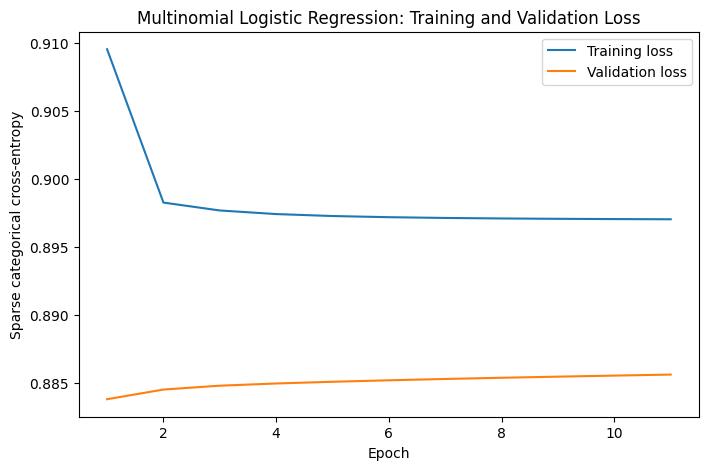

In [31]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index + 1,
    history_df["loss"],
    label="Training loss"
)

plt.plot(
    history_df.index + 1,
    history_df["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Sparse categorical cross-entropy")
plt.title(
    "Multinomial Logistic Regression: "
    "Training and Validation Loss"
)
plt.legend()

plt.show()

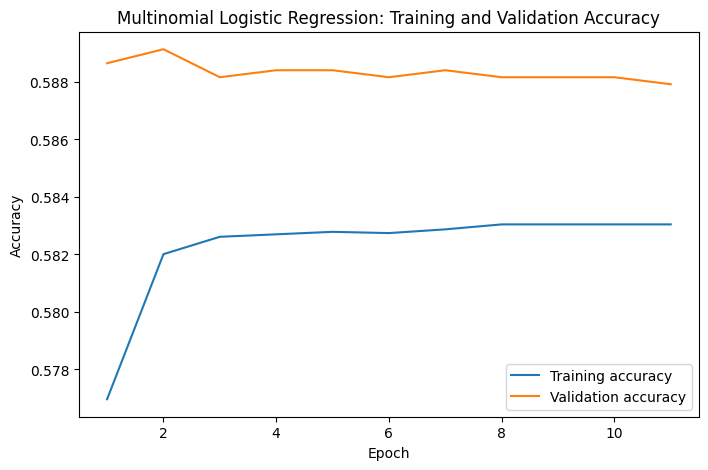

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index + 1,
    history_df["accuracy"],
    label="Training accuracy"
)

plt.plot(
    history_df.index + 1,
    history_df["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "Multinomial Logistic Regression: "
    "Training and Validation Accuracy"
)
plt.legend()

plt.show()

In [34]:
train_loss, train_accuracy = model.evaluate(
    X_train_array,
    y_train,
    verbose=0
)

validation_loss, validation_accuracy = model.evaluate(
    X_validation_array,
    y_validation,
    verbose=0
)

print(f"Training loss: {train_loss:.4f}")
print(f"Training accuracy: {train_accuracy:.4f}")

print(f"Validation loss: {validation_loss:.4f}")
print(
    f"Validation accuracy: "
    f"{validation_accuracy:.4f}"
)

Training loss: 0.8998
Training accuracy: 0.5829
Validation loss: 0.8838
Validation accuracy: 0.5887


In [35]:
validation_probabilities = model.predict(
    X_validation_array,
    verbose=0
)

validation_predictions = np.argmax(
    validation_probabilities,
    axis=1
)

print(validation_probabilities[:5])

print(
    "First five probability sums:",
    validation_probabilities[:5].sum(axis=1)
)

[[0.14564669 0.24002644 0.61432695]
 [0.48406607 0.3506304  0.1653035 ]
 [0.28603613 0.3803378  0.333626  ]
 [0.28050613 0.3911133  0.3283806 ]
 [0.3700091  0.37745932 0.25253156]]
First five probability sums: [1.0000001 1.        1.        1.        1.       ]


In [36]:
validation_log_loss = log_loss(
    y_validation,
    validation_probabilities,
    labels=class_ids
)

validation_macro_f1 = f1_score(
    y_validation,
    validation_predictions,
    average="macro"
)

print(
    f"Validation accuracy: "
    f"{validation_accuracy:.4f}"
)

print(
    f"Validation log loss: "
    f"{validation_log_loss:.4f}"
)

print(
    f"Validation macro F1: "
    f"{validation_macro_f1:.4f}"
)

Validation accuracy: 0.5887
Validation log loss: 0.8838
Validation macro F1: 0.4806


In [37]:
regularization_results = []

l2_candidates = [
    0.0,
    0.0001,
    0.001,
    0.01,
    0.1
]

for l2_strength in l2_candidates:
    print(
        f"\nTraining model with "
        f"L2 strength = {l2_strength}"
    )

    candidate_model = (
        build_multinomial_logistic_regression(
            input_dim=X_train_array.shape[1],
            learning_rate=0.01,
            l2_strength=l2_strength
        )
    )

    candidate_early_stopping = (
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            mode="min",
            verbose=0
        )
    )

    candidate_history = candidate_model.fit(
        X_train_array,
        y_train,
        validation_data=(
            X_validation_array,
            y_validation
        ),
        epochs=100,
        batch_size=32,
        callbacks=[candidate_early_stopping],
        verbose=0
    )

    candidate_validation_probs = (
        candidate_model.predict(
            X_validation_array,
            verbose=0
        )
    )

    candidate_validation_pred = np.argmax(
        candidate_validation_probs,
        axis=1
    )

    candidate_accuracy = accuracy_score(
        y_validation,
        candidate_validation_pred
    )

    candidate_log_loss = log_loss(
        y_validation,
        candidate_validation_probs,
        labels=class_ids
    )

    candidate_macro_f1 = f1_score(
        y_validation,
        candidate_validation_pred,
        average="macro"
    )

    regularization_results.append({
        "l2_strength": l2_strength,
        "epochs_trained": len(
            candidate_history.history["loss"]
        ),
        "validation_accuracy": candidate_accuracy,
        "validation_log_loss": candidate_log_loss,
        "validation_macro_f1": candidate_macro_f1
    })


Training model with L2 strength = 0.0

Training model with L2 strength = 0.0001

Training model with L2 strength = 0.001

Training model with L2 strength = 0.01

Training model with L2 strength = 0.1


In [38]:
regularization_results_df = pd.DataFrame(
    regularization_results
)

regularization_results_df.sort_values(
    by=[
        "validation_log_loss",
        "validation_macro_f1"
    ],
    ascending=[True, False]
)

,l2_strength,epochs_trained,validation_accuracy,validation_log_loss,validation_macro_f1
1,0.0001,11,0.589381,0.884179,0.479330
0,0.0000,11,0.589625,0.884578,0.480834
2,0.0010,29,0.591330,0.884966,0.477339
3,0.0100,11,0.592547,0.885572,0.458920
4,0.1000,11,0.588651,0.922636,0.420758


In [39]:
best_l2_strength = (
    regularization_results_df
    .sort_values(
        by=[
            "validation_log_loss",
            "validation_macro_f1"
        ],
        ascending=[True, False]
    )
    .iloc[0]["l2_strength"]
)

print("Selected L2 strength:", best_l2_strength)

Selected L2 strength: 0.0001


In [40]:
# Train final selected model
final_model = build_multinomial_logistic_regression(
    input_dim=X_train_array.shape[1],
    learning_rate=0.01,
    l2_strength=float(best_l2_strength)
)

final_early_stopping = (
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        mode="min",
        verbose=1
    )
)

final_history = final_model.fit(
    X_train_array,
    y_train,
    validation_data=(
        X_validation_array,
        y_validation
    ),
    epochs=100,
    batch_size=32,
    callbacks=[final_early_stopping],
    verbose=1
)

Epoch 1/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5786 - loss: 0.9070 - val_accuracy: 0.5894 - val_loss: 0.8851
Epoch 2/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5811 - loss: 0.9001 - val_accuracy: 0.5901 - val_loss: 0.8856
Epoch 3/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5813 - loss: 0.9001 - val_accuracy: 0.5908 - val_loss: 0.8857
Epoch 4/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5813 - loss: 0.9001 - val_accuracy: 0.5908 - val_loss: 0.8857
Epoch 5/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5813 - loss: 0.9000 - val_accuracy: 0.5908 - val_loss: 0.8857
Epoch 6/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5812 - loss: 0.9000 - val_accuracy: 0.5906 - val_loss: 0.8857
Epoch 7/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5812 - loss: 0.9000 - val_accuracy: 0.5906 - val_loss: 0.8857
Epoch 8/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5813 - loss: 0.9000 - val_accu

In [41]:
test_probabilities = final_model.predict(
    X_test_array,
    verbose=0
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

print("Probability matrix shape:", test_probabilities.shape)

print(
    "First five probability sums:",
    test_probabilities[:5].sum(axis=1)
)

Probability matrix shape: (102, 3)
First five probability sums: [1.         0.9999999  0.99999994 1.         1.0000001 ]


In [42]:
test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_log_loss = log_loss(
    y_test,
    test_probabilities,
    labels=class_ids
)

test_macro_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro"
)

test_weighted_f1 = f1_score(
    y_test,
    test_predictions,
    average="weighted"
)

print(
    f"2026 World Cup test accuracy: "
    f"{test_accuracy:.4f}"
)

print(
    f"2026 World Cup test log loss: "
    f"{test_log_loss:.4f}"
)

print(
    f"2026 World Cup test macro F1: "
    f"{test_macro_f1:.4f}"
)

print(
    f"2026 World Cup test weighted F1: "
    f"{test_weighted_f1:.4f}"
)

2026 World Cup test accuracy: 0.6765
2026 World Cup test log loss: 0.8487
2026 World Cup test macro F1: 0.5124
2026 World Cup test weighted F1: 0.5864


In [43]:
print(
    classification_report(
        y_test,
        test_predictions,
        labels=class_ids,
        target_names=class_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    away_win       0.70      0.87      0.78        30
        draw       0.00      0.00      0.00        24
    home_win       0.66      0.90      0.76        48

    accuracy                           0.68       102
   macro avg       0.45      0.59      0.51       102
weighted avg       0.52      0.68      0.59       102



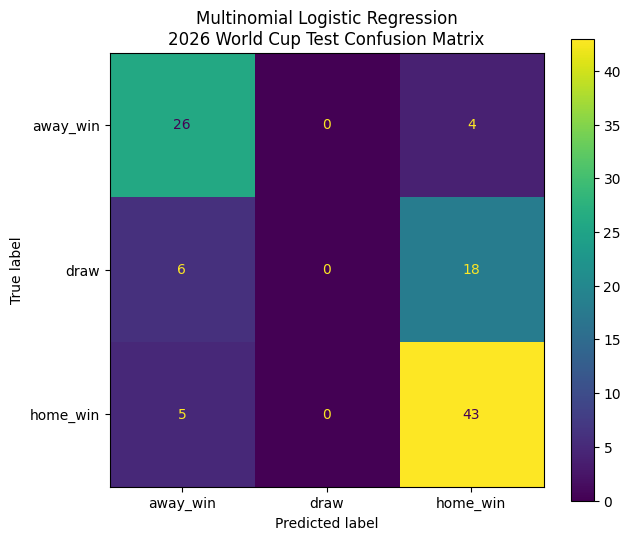

In [44]:
cm = confusion_matrix(
    y_test,
    test_predictions,
    labels=class_ids
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))

display.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "Multinomial Logistic Regression\n"
    "2026 World Cup Test Confusion Matrix"
)

plt.show()

In [48]:
test_readable = pd.read_csv(
    PROCESSED_DIR /
    "world_cup_2026_preprocessed_readable.csv"
)

assert len(test_readable) == len(test_probabilities), (
    "Readable and processed test files have different row counts."
)

test_results = test_readable[
    [
        "date",
        "home_team",
        "away_team",
        "elo_diff",
        "match_result"
    ]
].copy()

In [49]:
test_results["predicted_class_id"] = (
    test_predictions
)

test_results["predicted_result"] = [
    encoded_to_label[class_id]
    for class_id in test_predictions
]

In [50]:
for class_id, class_name in zip(
    class_ids,
    class_names
):
    probability_column = (
        f"prob_{class_name}"
    )

    test_results[probability_column] = (
        test_probabilities[:, class_id]
    )

test_results["correct_prediction"] = (
    test_results["match_result"] ==
    test_results["predicted_result"]
)

test_results.head()

,date,home_team,away_team,elo_diff,match_result,predicted_class_id,predicted_result,prob_away_win,prob_draw,prob_home_win,correct_prediction
0,2026-06-11,Mexico,South Africa,304.0,home_win,2,home_win,0.059953,0.176117,0.763930,True
1,2026-06-11,South Korea,Czech Republic,53.0,home_win,2,home_win,0.310047,0.278203,0.411750,True
2,2026-06-12,Canada,Bosnia and Herzegovina,231.0,draw,2,home_win,0.086340,0.204025,0.709634,False
3,2026-06-12,United States,Paraguay,-86.0,home_win,2,home_win,0.318192,0.292219,0.389589,True
4,2026-06-13,Qatar,Switzerland,-470.0,draw,0,away_win,0.802506,0.151427,0.046067,False


In [51]:
incorrect_predictions = test_results.loc[
    ~test_results["correct_prediction"]
].copy()

print(
    "Number of incorrect predictions:",
    incorrect_predictions.shape[0]
)

incorrect_predictions.head(20)

Number of incorrect predictions: 33


,date,home_team,away_team,elo_diff,match_result,predicted_class_id,predicted_result,prob_away_win,prob_draw,prob_home_win,correct_prediction
2,2026-06-12,Canada,Bosnia and Herzegovina,231.0,draw,2,home_win,0.086340,0.204025,0.709634,False
4,2026-06-13,Qatar,Switzerland,-470.0,draw,0,away_win,0.802506,0.151427,0.046067,False
5,2026-06-13,Brazil,Morocco,149.0,draw,2,home_win,0.219370,0.262067,0.518564,False
7,2026-06-13,Australia,Turkey,-106.0,home_win,0,away_win,0.483189,0.269885,0.246926,False
9,2026-06-14,Ivory Coast,Ecuador,-326.0,home_win,0,away_win,0.701166,0.203248,0.095586,False
10,2026-06-14,Netherlands,Japan,81.0,draw,2,home_win,0.281955,0.275023,0.443022,False
12,2026-06-15,Belgium,Egypt,258.0,draw,2,home_win,0.138835,0.229545,0.631619,False
13,2026-06-15,Iran,New Zealand,168.0,draw,2,home_win,0.203504,0.257282,0.539214,False
14,2026-06-15,Spain,Cape Verde,611.0,draw,2,home_win,0.022911,0.108511,0.868578,False
15,2026-06-15,Saudi Arabia,Uruguay,-278.0,draw,0,away_win,0.659479,0.220575,0.119946,False
